In [1]:
import warnings 
warnings.filterwarnings('ignore')

## K-Nearest-Neighbors

KNN falls in the supervised learning family of algorithms. Informally, this means that we are given a labelled dataset consiting of training observations (x,y) and would like to capture the relationship between x and y. More formally, our goal is to learn a function h:X→Y so that given an unseen observation x, h(x) can confidently predict the corresponding output y.

In this module we will explore the inner workings of KNN, choosing the optimal K values and using KNN from scikit-learn.

## Overview

1.Read the problem statement.

2.Get the dataset.

3.Explore the dataset.

4.Pre-processing of dataset.

5.Visualization

6.Transform the dataset for building machine learning model.

7.Split data into train, test set.

7.Build Model.

8.Apply the model.

9.Evaluate the model.

10.Finding Optimal K value

11.Repeat 7,8,9 steps.

## Problem statement

### Dataset

The data set we’ll be using is the Iris Flower Dataset which was first introduced in 1936 by the famous statistician Ronald Fisher and consists of 50 observations from each of three species of Iris (Iris setosa, Iris virginica and Iris versicolor). Four features were measured from each sample: the length and the width of the sepals and petals.

**Attributes of the dataset:** https://archive.ics.uci.edu/ml/datasets/Iris

**Train the KNN algorithm to be able to distinguish the species from one another given the measurements of the 4 features.**

## Question 1

Import the data set and print 10 random rows from the data set

In [52]:
import numpy as np
import pandas as pd
from sklearn.utils import resample
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn import model_selection
from sklearn import metrics
from sklearn.decomposition import PCA
from scipy.stats import zscore
from matplotlib import pyplot as plt 
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score, f1_score, auc, roc_curve


In [3]:
colnames = ['sepal length in cm', 'sepal width in cm', 'petal length in cm', 'petal width in cm','Class']
ir_df = pd.read_csv("iris.data",names= colnames)

In [4]:
ir_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
sepal length in cm    150 non-null float64
sepal width in cm     150 non-null float64
petal length in cm    150 non-null float64
petal width in cm     150 non-null float64
Class                 150 non-null object
dtypes: float64(4), object(1)
memory usage: 5.9+ KB


In [5]:
from random import sample
# get 10 random rows from df
dfr = ir_df.sample(n=10, random_state=0)
dfr

,sepal length in cm,sepal width in cm,petal length in cm,petal width in cm,Class
114,5.8,2.8,5.1,2.4,Iris-virginica
62,6.0,2.2,4.0,1.0,Iris-versicolor
33,5.5,4.2,1.4,0.2,Iris-setosa
107,7.3,2.9,6.3,1.8,Iris-virginica
7,5.0,3.4,1.5,0.2,Iris-setosa
100,6.3,3.3,6.0,2.5,Iris-virginica
40,5.0,3.5,1.3,0.3,Iris-setosa
86,6.7,3.1,4.7,1.5,Iris-versicolor
76,6.8,2.8,4.8,1.4,Iris-versicolor
71,6.1,2.8,4.0,1.3,Iris-versicolor


## Data Pre-processing

## Question 2 - Estimating missing values

*Its not good to remove the records having missing values all the time. We may end up loosing some data points. So, we will have to see how to replace those missing values with some estimated values (median) *

In [6]:
# There is no Null Value and '0' Value . But Safe side I will do Median
ir_df['sepal length in cm']=ir_df['sepal length in cm'].replace(0,ir_df['sepal length in cm'].median()) 
ir_df['sepal width in cm']=ir_df['sepal width in cm'].replace(0,ir_df['sepal width in cm'].median())
ir_df['petal length in cm']=ir_df['petal length in cm'].replace(0,ir_df['petal length in cm'].median())
ir_df['petal width in cm']=ir_df['petal width in cm'].replace(0,ir_df['petal width in cm'].median())

## Question 3 - Dealing with categorical data

Change all the classes to numericals (0to2).

In [7]:
# The first column is id column which is patient id and nothing to do with the model attriibutes. So drop it.
X = ir_df.drop("Class", axis=1)
from sklearn.preprocessing import LabelEncoder
lb_make = LabelEncoder()
ir_df["Class"] = lb_make.fit_transform(ir_df["Class"])
y = ir_df["Class"]

In [8]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
sepal length in cm    150 non-null float64
sepal width in cm     150 non-null float64
petal length in cm    150 non-null float64
petal width in cm     150 non-null float64
dtypes: float64(4)
memory usage: 4.8 KB


## Question 4

*Observe the association of each independent variable with target variable and drop variables from feature set having correlation in range -0.1 to 0.1 with target variable.*

In [9]:
# importing ploting libraries
import matplotlib.pyplot as plt   
#importing seaborn for statistical plots
import seaborn as sns
# To enable plotting graphs in Jupyter notebook
%matplotlib inline 

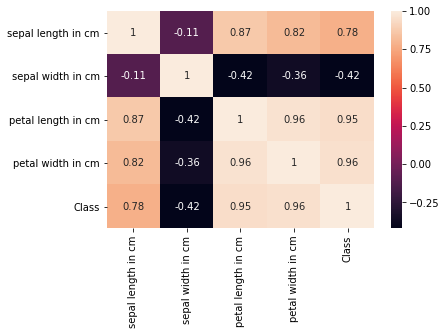

In [10]:
sns.heatmap(ir_df.corr(),annot=True)

In [11]:
# Correlation Factor from 1.00 to - 0.42. Hence all the features are strongly related

## Question 5

*Observe the independent variables variance and drop such variables having no variance or almost zero variance(variance < 0.1). They will be having almost no influence on the classification.*

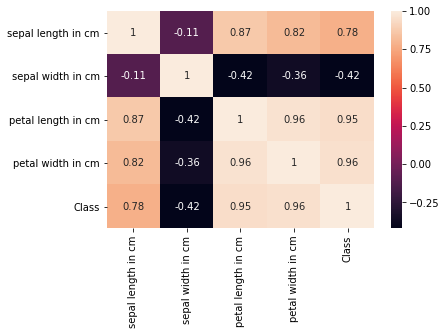

In [12]:
sns.heatmap(ir_df.corr(),annot=True)

In [13]:
#Sepal Width in cm correlation is less than <0.1. Hence drop from independent varible

In [14]:
X = X.drop("sepal width in cm", axis=1)

In [15]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 3 columns):
sepal length in cm    150 non-null float64
petal length in cm    150 non-null float64
petal width in cm     150 non-null float64
dtypes: float64(3)
memory usage: 3.6 KB


## Question 6

*Plot the scatter matrix for all the variables.*

In [16]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 3 columns):
sepal length in cm    150 non-null float64
petal length in cm    150 non-null float64
petal width in cm     150 non-null float64
dtypes: float64(3)
memory usage: 3.6 KB


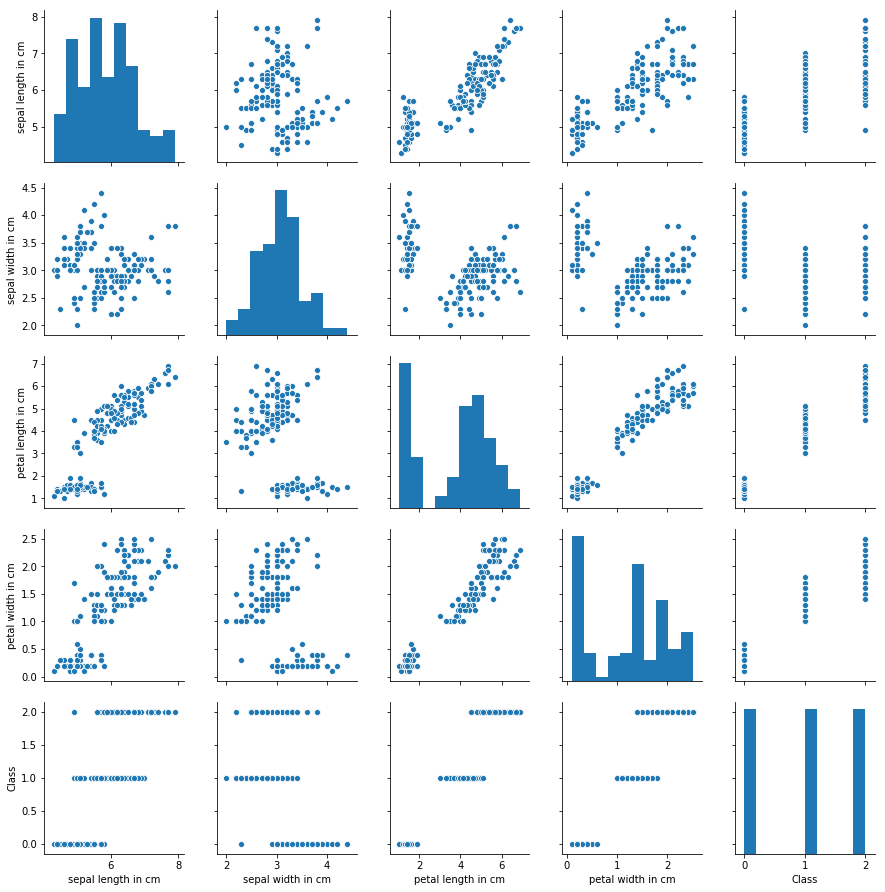

In [17]:
sns.pairplot(ir_df)

## Split the dataset into training and test sets

## Question 7

*Split the dataset into training and test sets with 80-20 ratio.*

In [18]:
#sc=StandardScaler()
#X=sc.fit_transform(X)

In [19]:
test_size = 0.20 # taking 80:30 training and test set
seed = 7  # Random numbmer seeding for reapeatability of the code
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)

## Question 8 - Model

*Build the model and train and test on training and test sets respectively using **scikit-learn**. Print the Accuracy of the model with different values of **k=3,5,9**.*

**Hint:** For accuracy you can check **accuracy_score()** in scikit-learn

In [20]:
from sklearn.neighbors import KNeighborsClassifier

In [21]:
Kvalues = [3,5,9]

for i in Kvalues:
    NNH = KNeighborsClassifier(n_neighbors= i)
    NNH.fit(X_train, y_train)
    ypred2=NNH.predict(X_test)
    testAccuracy=metrics.accuracy_score(y_test,ypred2)
    print("Accuracy Score(KValues =",i ,") ",testAccuracy)



Accuracy Score(KValues = 3 )  0.9
Accuracy Score(KValues = 5 )  0.9
Accuracy Score(KValues = 9 )  0.8666666666666667


## Question 9 - Cross Validation

Run the KNN with no of neighbours to be 1,3,5..19 and *Find the **optimal number of neighbours** from the above list using the Mis classification error

Hint:

Misclassification error (MSE) = 1 - Test accuracy score. Calculated MSE for each model with neighbours = 1,3,5...19 and find the model with lowest MSE

In [24]:
Kvalues = [1,3,5,7,9,11,13,15,17,19]
count = 0
MSE=[]
for i in Kvalues:
    NNH = KNeighborsClassifier(n_neighbors= i)
    NNH.fit(X_train, y_train)
    predicted_labels = NNH.predict(X_test)
    metrics.confusion_matrix(y_test, predicted_labels)
    ypred2=NNH.predict(X_test)
    testAccuracy=metrics.accuracy_score(y_test,ypred2)
    MSE.append (1 - testAccuracy)
    print("Mean Squre Value (KValues =",i ,") ", round(MSE[count],5))
    count=count+1

Mean Squre Value (KValues = 1 )  0.1
Mean Squre Value (KValues = 3 )  0.1
Mean Squre Value (KValues = 5 )  0.1
Mean Squre Value (KValues = 7 )  0.13333
Mean Squre Value (KValues = 9 )  0.13333
Mean Squre Value (KValues = 11 )  0.1
Mean Squre Value (KValues = 13 )  0.13333
Mean Squre Value (KValues = 15 )  0.1
Mean Squre Value (KValues = 17 )  0.06667
Mean Squre Value (KValues = 19 )  0.1


In [25]:
# The lowest MSE  0.0667 when K values is 17

## Question 10

*Plot misclassification error vs k (with k value on X-axis) using matplotlib.*

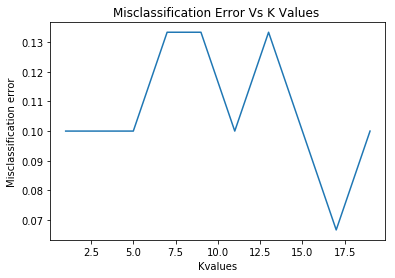

In [27]:
plt.title("Misclassification Error Vs K Values ") 
plt.xlabel("Kvalues") 
plt.ylabel("Misclassification error") 
plt.plot(Kvalues,MSE) 
plt.show()

# Naive Bayes with Iris Data

In [28]:
#Load all required library
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline
from sklearn import datasets
from sklearn.decomposition import PCA
from sklearn import preprocessing
from sklearn.naive_bayes import GaussianNB, BernoulliNB, MultinomialNB

### Slice  Iris data set for Independent variables and dependent variables
#### Please note 'Species' is my dependent variables, name it y and independent set data as X

In [29]:
colnames = ['sepal length in cm', 'sepal width in cm', 'petal length in cm', 'petal width in cm','Class']
ir_df = pd.read_csv("iris.data",names= colnames)

In [30]:
# The first column is id column which is patient id and nothing to do with the model attriibutes. So drop it.
X = ir_df.drop("Class", axis=1)
from sklearn.preprocessing import LabelEncoder
lb_make = LabelEncoder()
ir_df["Class"] = lb_make.fit_transform(ir_df["Class"])
y = ir_df["Class"]

In [31]:
#Check the dataset
print(y)
print(X)

0      0
1      0
2      0
3      0
4      0
5      0
6      0
7      0
8      0
9      0
10     0
11     0
12     0
13     0
14     0
15     0
16     0
17     0
18     0
19     0
20     0
21     0
22     0
23     0
24     0
25     0
26     0
27     0
28     0
29     0
      ..
120    2
121    2
122    2
123    2
124    2
125    2
126    2
127    2
128    2
129    2
130    2
131    2
132    2
133    2
134    2
135    2
136    2
137    2
138    2
139    2
140    2
141    2
142    2
143    2
144    2
145    2
146    2
147    2
148    2
149    2
Name: Class, Length: 150, dtype: int32
     sepal length in cm  sepal width in cm  petal length in cm  \
0                   5.1                3.5                 1.4   
1                   4.9                3.0                 1.4   
2                   4.7                3.2                 1.3   
3                   4.6                3.1                 1.5   
4                   5.0                3.6                 1.4   
5               

# Question 11 
Find the distribution of target variable (Class)

And, Plot the distribution of target variable using histogram

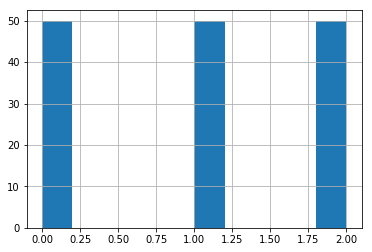

In [32]:
# histograms
y.hist()
plt.show()

In [28]:
#Drop Id variable from data::::????Where is ID Coming?

### Question 12 
Find Correlation among all variables and give your insights 

In [33]:
#Please note, it's Require to remove correlated features because they are voted twice in the model and 
## it can lead to over inflating importance.We will ignore it here

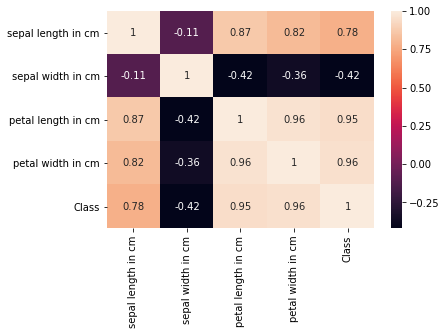

In [34]:
sns.heatmap(ir_df.corr(),annot=True)

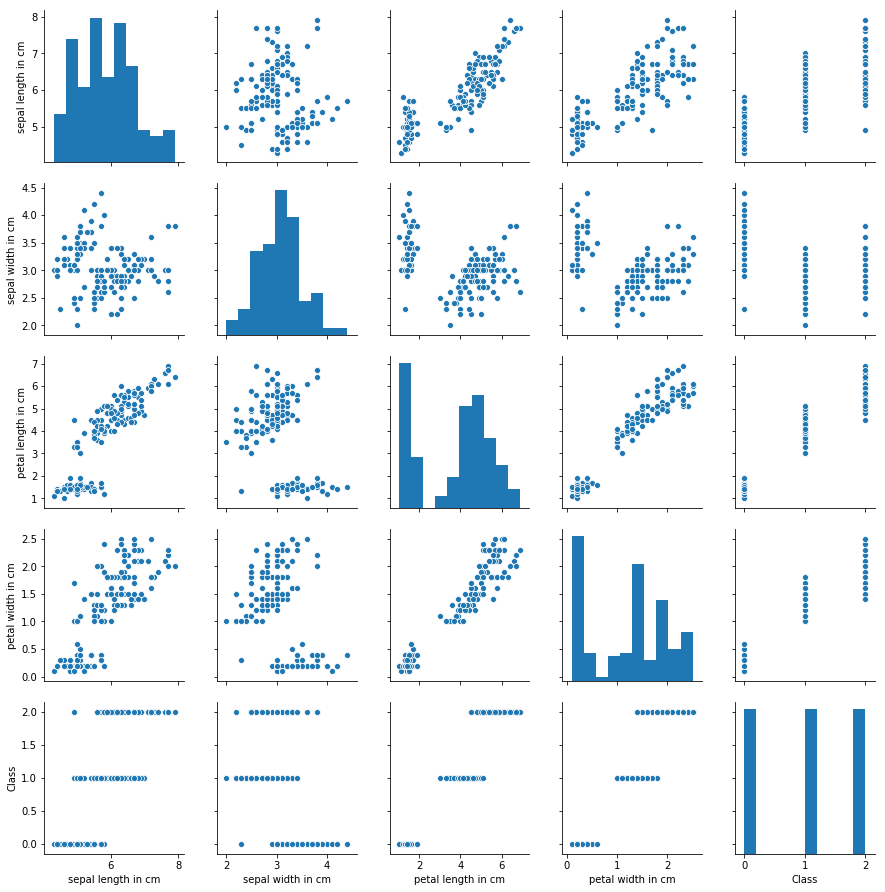

In [35]:
#Sepal Width in cm correlation is less than <0.1. 
sns.pairplot(ir_df)

In [36]:
#Petal Length and Petal Width is strongly dependent on class 
#There is no relastion between class and sepal width
#There is strong relationship between Sepal Length and class.

### Split data in Training and test set in 80:20.

In [37]:
test_size = 0.20 # taking 80:20 training and test set
seed = 7  # Random numbmer seeding for reapeatability of the code
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)

### Question 13 
Do Feature Scaling 

In [38]:
# Use StandardScaler or similar methods
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
sepal length in cm    150 non-null float64
sepal width in cm     150 non-null float64
petal length in cm    150 non-null float64
petal width in cm     150 non-null float64
dtypes: float64(4)
memory usage: 4.8 KB


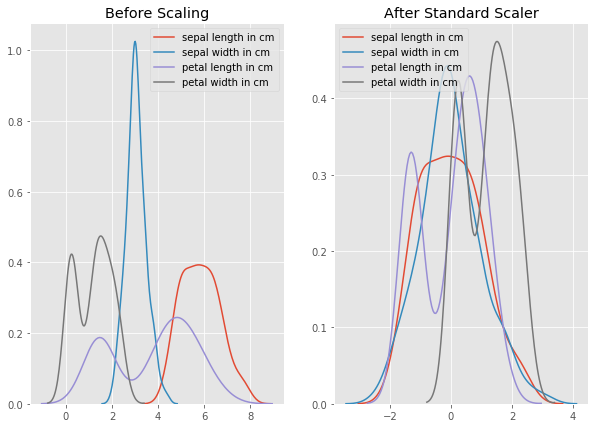

In [41]:

from sklearn import preprocessing
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
matplotlib.style.use('ggplot')

scaler = preprocessing.StandardScaler()
scaled_df = scaler.fit_transform(X)
scaled_df = pd.DataFrame(scaled_df, columns=['sepal length in cm','sepal width in cm', 'petal length in cm', 'petal width in cm'])
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(10, 7))


ax1.set_title('Before Scaling')
sns.kdeplot(ir_df['sepal length in cm'], ax=ax1)
sns.kdeplot(ir_df['sepal width in cm'], ax=ax1)
sns.kdeplot(ir_df['petal length in cm'], ax=ax1)
sns.kdeplot(ir_df['petal width in cm'], ax=ax1)
ax2.set_title('After Standard Scaler')
sns.kdeplot(scaled_df['sepal length in cm'], ax=ax2)
sns.kdeplot(scaled_df['sepal width in cm'], ax=ax2)
sns.kdeplot(scaled_df['petal length in cm'], ax=ax2)
sns.kdeplot(ir_df['petal width in cm'], ax=ax2)
plt.show()

In [42]:
X=scaled_df

In [43]:
test_size = 0.20 # taking 80:20 training and test set
seed = 7  # Random numbmer seeding for reapeatability of the code
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)

### Question 14 
Train and Fit NaiveBayes Model

In [44]:
#Fit the model
model = GaussianNB()
model.fit(X_train, y_train)
print(model)

GaussianNB(priors=None, var_smoothing=1e-09)


In [45]:
#Predict
predicted = model.predict(X_test)

### Question 15 
Print Accuracy and Confusion Matrix and Conclude your findings

In [46]:
# show Confusion Matrix
metrics.confusion_matrix(y_test,predicted)

array([[7, 0, 0],
       [0, 9, 3],
       [0, 2, 9]], dtype=int64)

In [47]:
# show accuracy
sum(y_test)

34

In [48]:
#Show precision and Recall metrics

In [54]:
y_predictProb = model.predict_proba(X_test)

In [92]:
THRESHOLD = 0.2
preds = np.where(model.predict_proba(X_test)[:,1] > THRESHOLD, 1, 0)
pd.DataFrame(data=[recall_score(y_test, preds,average='macro'),
                   precision_score(y_test, preds,average='macro'),
                   f1_score(y_test, preds,average='macro')], 
             index=["Recall", "Precision", "f1Score"])

C:\Users\apichu\Anaconda3\lib\site-packages\sklearn\metrics\classification.py:1143: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples.
  'precision', 'predicted', average, warn_for)
C:\Users\apichu\Anaconda3\lib\site-packages\sklearn\metrics\classification.py:1143: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no predicted samples.
  'precision', 'predicted', average, warn_for)


,0
Recall,0.611111
Precision,0.407407
f1Score,0.464444


# For Practice  - Optional

All the questions from 16 to 20 are for practice.

# Using SVM with Diebetes Dataset

In [0]:
#Import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Question 16 
Read the input file 'Diabetes.csv' using Pandas and check it's column names.

Check dimension of dataset.

Check distribution of dependent variable, Outcome and plot it.


In [0]:
# Eye ball the imported dataset

### Out of  768 data points, 500 are labeled as 0 and 268 as 1.
### Outcome 0 means No diabetes, outcome 1 means diabetes

In [0]:
# Check data types and info of dataset

# Question 17 
Check data distribution using summary statistics and provide your findings.

Do correlation analysis and bivariate viualization with Insights


# Question 18 
Do train and test split. 
Optionally - You can do with stratify sampling(optional) on Outcome variable to maintain the distribution of dependent variable

# Question 19 
Train Support Vector Machine Model(1 Marks)

In [0]:
# use from sklearn.svm import SVC

In [0]:
# your insights

# Question 20
Scale the data points using MinMaxScaler

Fit SVM Model on Scale data and give your observation

#we can try increasing either C or gamma to fit a more complex model.

# Optional Question - 
Try improving the model accuracy using C=1000 (1 Marks)

### Here, increasing C allows us to improve the model, resulting in ??? accuracy.
### Let's try to explore different Kernel and C (Bonus for practice)

In [0]:
import multiprocessing 
from sklearn.model_selection import GridSearchCV

In [0]:
 param_grid = [    {        
     'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],        
     'C': [ 0.1, 0.2, 0.4, 0.5, 1.0, 1.5, 1.8, 2.0, 2.5, 3.0 ]    } ]

In [0]:
gs = GridSearchCV(estimator=SVC(), param_grid=param_grid,scoring='accuracy', cv=10, n_jobs=multiprocessing.cpu_count())

In [0]:
gs.fit(X_train_scaled, y_train) 

GridSearchCV(cv=10, error_score='raise',
       estimator=SVC(C=1.0, cache_size=200, class_weight=None, coef0=0.0,
  decision_function_shape=None, degree=3, gamma='auto', kernel='rbf',
  max_iter=-1, probability=False, random_state=None, shrinking=True,
  tol=0.001, verbose=False),
       fit_params={}, iid=True, n_jobs=4,
       param_grid=[{'kernel': ['linear', 'rbf', 'poly', 'sigmoid'], 'C': [0.1, 0.2, 0.4, 0.5, 1.0, 1.5, 1.8, 2.0, 2.5, 3.0]}],
       pre_dispatch='2*n_jobs', refit=True, return_train_score=True,
       scoring='accuracy', verbose=0)

In [0]:
gs.best_estimator_

SVC(C=2.5, cache_size=200, class_weight=None, coef0=0.0,
  decision_function_shape=None, degree=3, gamma='auto', kernel='linear',
  max_iter=-1, probability=False, random_state=None, shrinking=True,
  tol=0.001, verbose=False)

In [0]:
gs.best_score_ 

0.77777777777777779